# Graphic 1: Temperature Anomalies over Land and over Ocean

This notebook replicates the GISTEMP v4 graphic
[Temperature Anomalies over Land and over Ocean](https://data.giss.nasa.gov/gistemp/graphs_v4/graph_data/Temperature_Anomalies_over_Land_and_over_Ocean/graph.html)
published by NASA's Goddard Institute for Space Studies (GISS).

The figure shows annual mean surface-air temperature anomalies over **land**
and over the **ocean** relative to the 1951-1980 mean, together with a
5-year lowess smoothing of each series.

**Data:** `data/land_ocean_anomalies.csv`
(GISTEMP v4, downloaded with `scripts/download_data.py`).

## Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import MultipleLocator

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

## Load the data

The raw CSV has one title line before the header row, which is skipped below.
The four numeric columns are the land annual mean, its lowess smoothing, the
ocean annual mean, and its lowess smoothing.

In [2]:
df = pd.read_csv(
    DATA_DIR / "land_ocean_anomalies.csv",
    skiprows=1,
    header=0,
    names=["Year", "Land_Annual", "Land_Lowess", "Ocean_Annual", "Ocean_Lowess"],
)
print("shape:", df.shape)
df.head()

shape: (146, 5)


,Year,Land_Annual,Land_Lowess,Ocean_Annual,Ocean_Lowess
0,1880,-0.68,-0.55,-0.05,0.01
1,1881,-0.46,-0.58,0.01,-0.02
2,1882,-0.54,-0.61,0.00,-0.06
3,1883,-0.61,-0.64,-0.06,-0.09
4,1884,-0.78,-0.66,-0.15,-0.12


In [3]:
df.tail()

,Year,Land_Annual,Land_Lowess,Ocean_Annual,Ocean_Lowess
141,2021,1.30,1.48,0.57,0.70
142,2022,1.30,1.56,0.61,0.74
143,2023,1.68,1.64,0.86,0.78
144,2024,1.90,1.72,0.93,0.82
145,2025,1.75,1.80,0.82,0.87


## Build the figure

The colours and line styles follow the original NASA graphic:

| Series | Colour | Style |
| --- | --- | --- |
| Land annual mean | `#FFA500` (orange) | thin line, square markers |
| Land lowess smoothing | `#FF0000` (red) | thick line |
| Ocean annual mean | `#87CEEB` (sky blue) | thin line, square markers |
| Ocean lowess smoothing | `#0000FF` (blue) | thick line |

The y-axis is in degrees Celsius relative to the 1951-1980 base period.

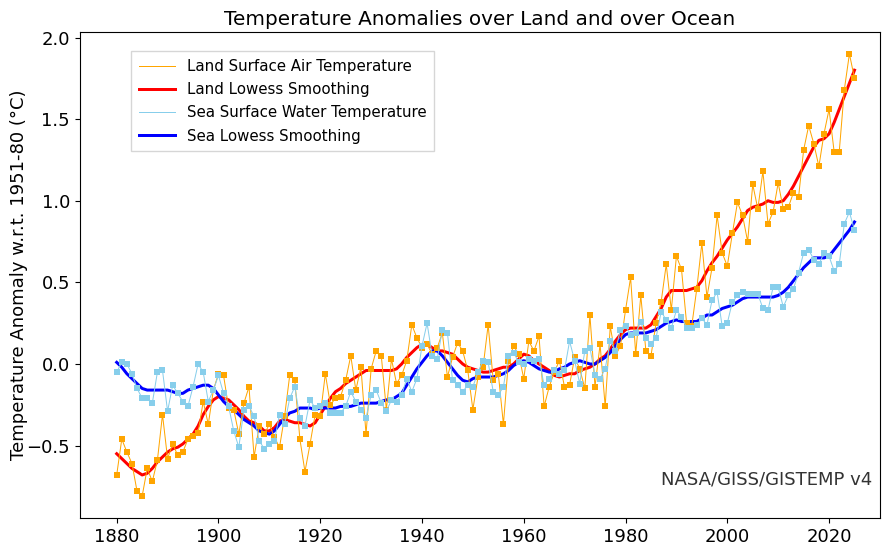

In [4]:
fig = plt.figure(figsize=(9.04, 5.6), dpi=100)
ax = fig.add_axes([0.1016, 0.0692, 0.8851, 0.8688])

ax.plot(df.Year, df.Land_Annual, color="#FFA500", lw=0.72,
        marker="s", ms=4.3, mew=0, zorder=3)
ax.plot(df.Year, df.Land_Lowess, color="#FF0000", lw=2.16, zorder=2)
ax.plot(df.Year, df.Ocean_Annual, color="#87CEEB", lw=0.72,
        marker="s", ms=4.3, mew=0, zorder=3)
ax.plot(df.Year, df.Ocean_Lowess, color="#0000FF", lw=2.16, zorder=2)

ax.set_xlim(1872.75, 2030)
ax.set_ylim(-0.9455, 2.0355)
ax.set_xticks(range(1880, 2021, 20))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.tick_params(labelsize=12.96)

ax.text(0.5, 1.014, "Temperature Anomalies over Land and over Ocean",
        transform=ax.transAxes, ha="center", va="baseline", fontsize=14.4)
ax.text(-0.076, 0.5, "Temperature Anomaly w.r.t. 1951-80 (\N{DEGREE SIGN}C)",
        transform=ax.transAxes, ha="center", va="center", rotation=90,
        fontsize=12.96)
ax.text(0.99, 0.07, "NASA/GISS/GISTEMP v4", transform=ax.transAxes,
        ha="right", va="baseline", fontsize=12.96, alpha=0.8)

handles = [
    Line2D([], [], color="#FFA500", lw=0.72),
    Line2D([], [], color="#FF0000", lw=2.16),
    Line2D([], [], color="#87CEEB", lw=0.72),
    Line2D([], [], color="#0000FF", lw=2.16),
]
labels = ["Land Surface Air Temperature", "Land Lowess Smoothing",
          "Sea Surface Water Temperature", "Sea Lowess Smoothing"]
ax.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.055, 0.975),
          fontsize=10.8, framealpha=0.8, edgecolor="#cccccc", fancybox=False,
          labelspacing=0.55, borderpad=0.5, handlelength=2.4)

## Save and display

The figure is saved in `outputs/` as both PNG (raster) and PDF (vector).

In [5]:
fig.savefig(OUTPUT_DIR / "graphic1_land_ocean_anomalies.png", dpi=100)
fig.savefig(OUTPUT_DIR / "graphic1_land_ocean_anomalies.pdf")
plt.show()

Both annual series show the well-known warming trend, and the land surface
warms faster (and is noisier) than the ocean surface. The figure is a close
replication of the NASA original; the only differences are font rendering and
minor sub-pixel positioning of the labels.